## Calidad de sueño y estilo de vida
En este conjunto de datos sacado de Kaggle cuenta con datos de la calidad de sueño de distintas personas, las columnas que se encuentran son las siguientes:
* Person ID: Un identificador para cada persona
* Gener: El género de la persona 
* Age: La edad de las personas en años
* Occupation: - La ocupación o profesión 
* Sleep Duration (hours) - El número de horas que la persona duerme por día
* Quality Sleep (scale: 1-10) - Una calificación subjetiva de la calidad del sueño
* Physical Activity Level (minutes/day) - El número de minutos que la persona hace actividad física diariamente
* Stress Level (scale: 1-10) - Una calificacoón subjetiva del nivel de estres experimentado por la persona
* BMI Category - La categoría de Índice de Masa Corporal
* Blood Pressure (systolic/diastolic) - La presión arterial de la persona, indicado como presión sistólica sobre presión diastólica
* Heart Rate (bpm) - La frecuencia cardíaca en reposo en latidos por minuto
* Dialy Steps - El número de pasos que la persona hace al día
* Sleep Disorder - La presencia o ausensica de transtornos del sueño en la persona.

### Preguntas que buscamos responder con este conjunto
Las preguntas que buscaremos responder con este conjunto de datos son las siguientes:

* ¿Quiénes tienen peor calidad del sueño, hombres o mujeres? 
* ¿Existe una relación entre la calidad del sueño de las personas y su profesión?
* ¿La actividad física afecta al sueño?
* ¿Qué profesión presenta la peor calidad de sueño?
* ¿Cuál profesión tienen a las personas con el mayor nivel de estrés y el mayor índice de masa corporal?
* ¿En qué rango de edades se encuentran la mayor cantidad de trastornos del sueño?
* La cantidad de pasos al día, ¿afecta la calidad del sueño? ¿al índice de masa corporal?

In [1]:
import pandas as pd

data = pd.read_csv("Sleep_health_and_lifestyle_dataset.csv")
data.head()


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [2]:
# informacion de la data
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


In [3]:
data.describe()

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,187.500000,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920
std,108.108742,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,94.250000,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000
50%,187.500000,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000
75%,280.750000,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,374.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


In [4]:
# Promedio de la calidad del sueño por género
data.groupby('Gender')["Quality of Sleep"].mean()

Gender
Female    7.664865
Male      6.968254
Name: Quality of Sleep, dtype: float64

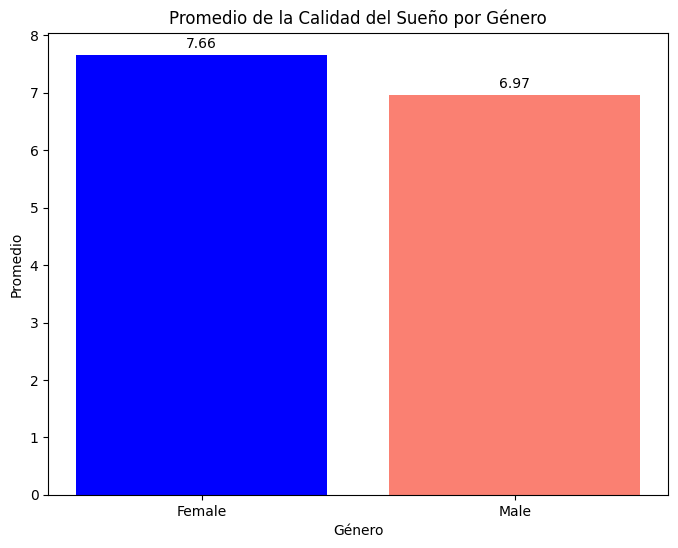

In [5]:
import matplotlib.pyplot as plt

promedio_sueño = data.groupby('Gender')["Quality of Sleep"].mean()
fig, ax = plt.subplots(figsize=(8, 6))
barras = ax.bar(promedio_sueño.index, promedio_sueño.values, color=["blue", "salmon"])

plt.title("Promedio de la Calidad del Sueño por Género")
plt.xlabel("Género")
plt.ylabel("Promedio")
ax.bar_label(barras, fmt="%.2f", padding=3)

plt.show()

In [ ]:
cantidad = data["Occupation"].value_counts()
cantidad_validas = cantidad[cantidad > 10].index #ajustar el valor de 10 según sea necesario
df_f = data[data["Occupation"].isin(cantidad_validas)]

In [16]:
resumen = (df_f.groupby("Occupation")["Quality of Sleep"]
        .agg(["count","mean", "median", "std", "min", "max"])
        .sort_values("mean", ascending=False)
        .round(2))
resumen

,count,mean,median,std,min,max
Occupation,,,,,,
Engineer,63,8.41,9.0,0.75,5,9
Lawyer,47,7.89,8.0,0.31,7,8
Accountant,37,7.89,8.0,0.46,7,9
Nurse,73,7.37,6.0,1.55,5,9
Teacher,40,6.98,7.0,0.66,5,8
Doctor,71,6.65,7.0,0.76,6,9
Salesperson,32,6.00,6.0,0.00,6,6


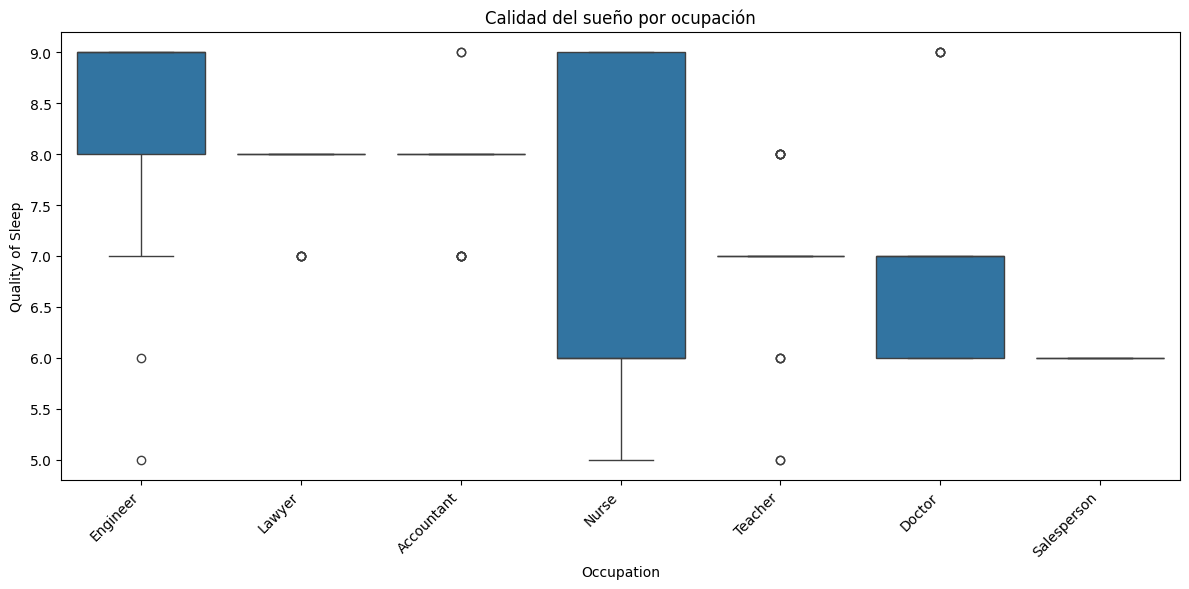

In [22]:
import seaborn as sns

orden = resumen.index

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_f, x="Occupation", y="Quality of Sleep", order=orden)
plt.xticks(rotation=45, ha="right")
plt.title("Calidad del sueño por ocupación")
plt.tight_layout()
plt.show()

#### CONCLUSIÓN DEL GRÁFICO:
La calidad del sueño varía según la ocupación. Los Engineers presentan la mejor calidad (la mayoría entre 8 y 9), seguidos de Lawyers y Accountants, que se concentran alrededor de 8. Teachers se ubican cerca de 7, Doctors entre 6 y 7, y Salesperson tiene la más baja (todas sus observaciones son 6).
Los Nurses muestran la mayor dispersión (de 5 a 9), lo que indica que su calidad de sueño es muy heterogénea. En general, el gráfico sugiere que sí existe una relación entre la profesión y la calidad del sueño, pero falta confirmarla con una prueba estadística.

In [ ]:
import scipy.stats as stats
grupos = [g["Quality of Sleep"].values for _, g in df_f.groupby("Occupation")]
h, p = stats.kruskal(*grupos)
print(f"H = {h:.4f}, p = {p:.4f}")

H = 154.1392, p = 0.0000


In [ ]:
n = len(df_f)
k = df_f["Occupation"].nunique()
epsilon2 = (h - k + 1) / (n - k)
print(f"Epsilon² = {epsilon2:.3f}")
# ~0.01 pequeño | ~0.08 mediano | ~0.26 grande

Epsilon² = 0.416


### Conclucion Final
La prueba de Kruskal-Wallis dio H = 154.14 y p < 0.001. Como p < 0.05, existe una relación estadísticamente significativa entre la profesión y la calidad del sueño. El tamaño del efecto (epsilon² = 0.416) indica una relación grande, es decir, la ocupación está fuertemente asociada con la calidad del sueño. 
Las ocupaciones con mejor calidad de sueño son Engineer y Lawyer, mientras que las de peor calidad son Salesperson y Doctor. Nurse muestra la mayor variabilidad interna. Limitación: es un estudio observacional con una muestra pequeña (374 registros), por lo que la relación no implica causalidad; factores como el nivel de estrés, la edad o las horas de sueño podrían influir en el resultado.

In [28]:
# ¿La actividad física afecta el sueño?
for var in ["Quality of Sleep", "Sleep Duration"]:
    rho, p =stats.spearmanr(data["Physical Activity Level"], data[var])
    print(f"Actividad fisica vs {var}: rho = {rho:.3f}, p = {p:.4g}")

Actividad fisica vs Quality of Sleep: rho = 0.178, p = 0.0005249
Actividad fisica vs Sleep Duration: rho = 0.209, p = 4.541e-05


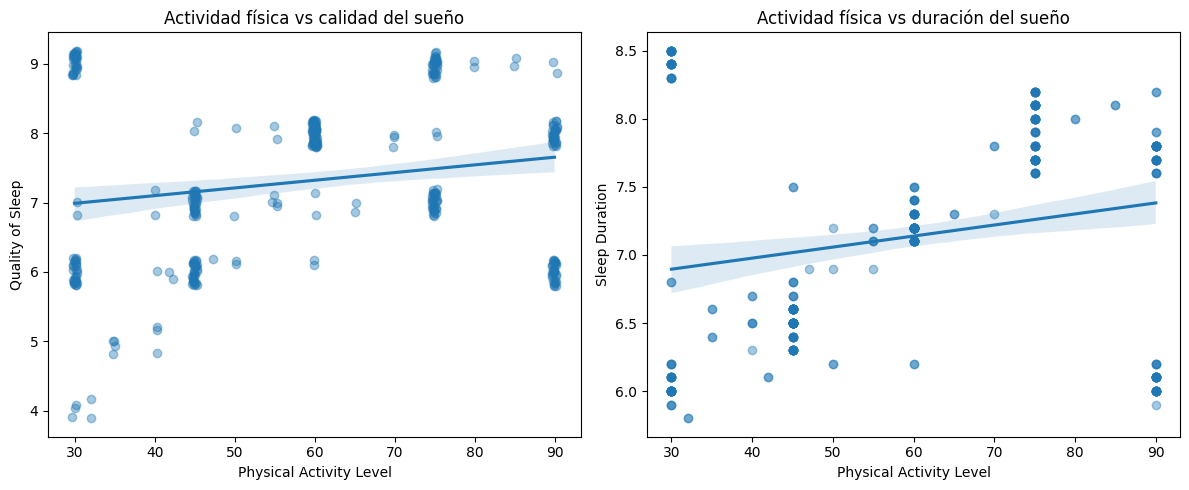

In [29]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.regplot(data=data, x="Physical Activity Level", y="Quality of Sleep",
            x_jitter=0.3, y_jitter=0.2, scatter_kws={"alpha": 0.4}, ax=ax[0])
ax[0].set_title("Actividad física vs calidad del sueño")
sns.regplot(data=data, x="Physical Activity Level", y="Sleep Duration",
            scatter_kws={"alpha": 0.4}, ax=ax[1])
ax[1].set_title("Actividad física vs duración del sueño")
plt.tight_layout()
plt.show()

### CONCLUSIÓN:
La correlación de Spearman entre actividad física y calidad del sueño fue
 rho = 0.178 (p < 0.001), y con la duración del sueño rho = 0.209 (p < 0.001).
 Ambas relaciones son positivas y estadísticamente significativas, pero de magnitud
 débil: a mayor actividad física tiende a haber algo más de calidad y duración del
 sueño, aunque la actividad física explica solo una pequeña parte de la variación.
 Los gráficos de dispersión lo confirman: la tendencia es ascendente pero con mucha
 dispersión.


In [31]:
# Ocupaciones ordenadas de peor a mejor calidad de sueño (promedio)
peor = (df_f.groupby("Occupation")["Quality of Sleep"]
            .agg(["count", "mean", "median"])
            .sort_values("mean")        # orden ascendente: la primera fila es la peor
            .round(2))
print(peor)

print("Peor profesión:", peor.index[0])

             count  mean  median
Occupation                      
Salesperson     32  6.00     6.0
Doctor          71  6.65     7.0
Teacher         40  6.98     7.0
Nurse           73  7.37     6.0
Accountant      37  7.89     8.0
Lawyer          47  7.89     8.0
Engineer        63  8.41     9.0
Peor profesión: Salesperson


### CONCLUSIÓN:
La profesión con peor calidad de sueño es Salesperson (promedio = 6.0), seguida de
 Doctor. 

In [32]:
#¿Cuál profesión tienen a las personas con el mayor nivel de estrés y el mayor índice de masa corporal?
print(data["BMI Category"].unique())

['Overweight' 'Normal' 'Obese' 'Normal Weight']


In [ ]:
# vemos el nievl de estrés promedio por ocupación
estres = (df_f.groupby("Occupation")["Stress Level"]
        .mean()
        .sort_values(ascending=False)
        .round(2))
estres

Occupation
Salesperson    7.00
Doctor         6.73
Nurse          5.55
Lawyer         5.06
Accountant     4.59
Teacher        4.53
Engineer       3.89
Name: Stress Level, dtype: float64

In [ ]:
# creamos una nueva columna para identificar si la persona tiene sobrepeso u obesidad
df_f = df_f.copy()
df_f["Sobrepeso_Obesidad"] = df_f["BMI Category"].isin(["Overweight", "Obese"])

imc = (df_f.groupby("Occupation")["Sobrepeso_Obesidad"].mean().mul(100).sort_values(ascending=False).round(1))
imc


Occupation
Salesperson    100.0
Nurse           90.4
Teacher         85.0
Accountant      16.2
Lawyer           8.5
Doctor           5.6
Engineer         4.8
Name: Sobrepeso_Obesidad, dtype: float64

In [41]:
# agrupamos los resultados en una tabla
tabla = pd.concat([estres, imc], axis=1)
tabla.columns = ["Estrés promedio", "Porcentaje de Sobrepeso/Obesidad"]
print(tabla.sort_values("Estrés promedio", ascending=False))

             Estrés promedio  Porcentaje de Sobrepeso/Obesidad
Occupation                                                    
Salesperson             7.00                             100.0
Doctor                  6.73                               5.6
Nurse                   5.55                              90.4
Lawyer                  5.06                               8.5
Accountant              4.59                              16.2
Teacher                 4.53                              85.0
Engineer                3.89                               4.8


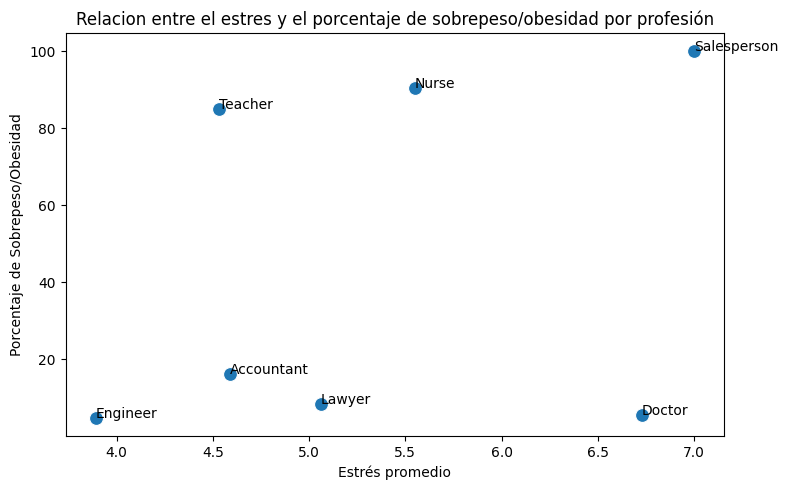

In [42]:
# graficamos
plt.figure(figsize=(8, 5))
sns.scatterplot(data=tabla, x="Estrés promedio", y="Porcentaje de Sobrepeso/Obesidad", s=100)
for ocupacion, fila in tabla.iterrows():          # escribe el nombre de cada profesión sobre su punto
    plt.text(fila["Estrés promedio"], fila["Porcentaje de Sobrepeso/Obesidad"], ocupacion)
plt.title("Relacion entre el estres y el porcentaje de sobrepeso/obesidad por profesión")
plt.tight_layout()
plt.show()

### CONCLUSIÓN:
La profesión con mayor nivel de estrés promedio es Salesperson (≈ 7.0), y también
 es la que tiene el mayor porcentaje de personas con sobrepeso u obesidad (≈ 100%),
 por lo que es la que combina ambos factores. Le siguen Nurse (≈ 90% de sobrepeso)
 y Doctor (segundo mayor estrés, ≈ 6.7, pero con muy poco sobrepeso).
 El gráfico muestra que el estrés alto no siempre va con sobrepeso: Doctor tiene
 estrés alto sin sobrepeso, y Teacher tiene sobrepeso con estrés bajo.

In [51]:
# creamos rangos y etiquetas 
rango = [26, 30, 35, 40, 45, 50, 60]
etiquetas = ["27-30", "31-35", "36-40", "41-45", "46-50", "51-59"]
data["Rango Edad"] = pd.cut(data["Age"], bins=rango, labels=etiquetas)
#personas con trastorno del sueño
con_transtorno = data[data["Sleep Disorder"].notna()] 

# contamos cuantos tienen transtorno, en el rango
sum_transtorno = data[data["Sleep Disorder"].notna()]

conteo = con_transtorno["Rango Edad"].value_counts().sort_index()
conteo

Rango Edad
27-30     9
31-35     5
36-40     8
41-45    62
46-50    31
51-59    40
Name: count, dtype: int64

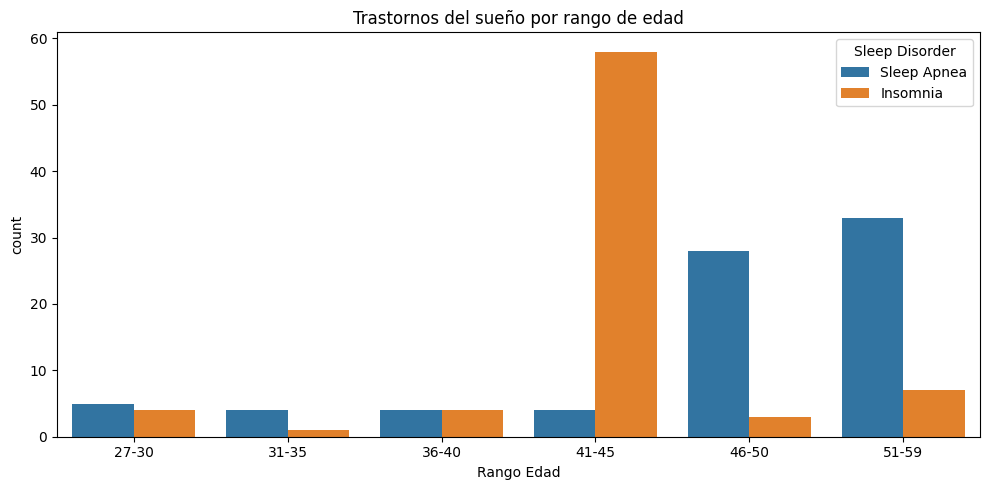

In [52]:
# grafico
plt.figure(figsize=(10, 5))
sns.countplot(data=con_transtorno, x="Rango Edad", hue="Sleep Disorder", order=etiquetas)
plt.title("Trastornos del sueño por rango de edad")
plt.tight_layout()
plt.show()

### CONCLUSIÓN:
El rango de edad con mayor cantidad de trastornos del sueño es 41-45 años
 (≈ 62 casos), donde predomina ampliamente el insomnio (≈ 58 casos).
 A partir de los 46 años predomina la apnea del sueño (≈ 28 casos en 46-50 y
 ≈ 33 en 51-59). Entre los 27 y 40 años hay pocos casos en general.
 Es decir, los trastornos aumentan con la edad y el tipo de trastorno cambia:
 insomnio alrededor de los 41-45 y apnea en edades mayores.

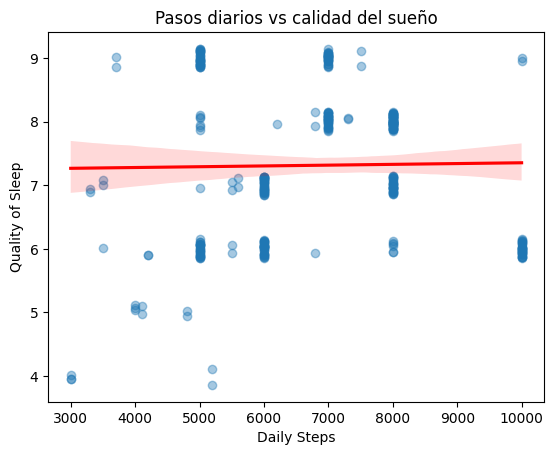

In [ ]:
# La cantidad de pasos al día, ¿afecta la calidad del sueño? ¿al índice de masa corporal?
data["BMI Category"] = data["BMI Category"].replace("Normal Weight", "Normal")

# gráfico de dispersión 
sns.regplot(data=data, x="Daily Steps", y="Quality of Sleep", y_jitter=0.15,
            scatter_kws={"alpha": 0.4}, line_kws={"color": "red"})
plt.title("Pasos diarios vs calidad del sueño")
plt.show()

### CONCLUSIÓN DEL GRÁFICO 
 La línea de tendencia es prácticamente plana y los puntos se reparten por todo
 el gráfico: con cualquier cantidad de pasos hay personas con calidad de sueño
 baja y alta. Esto coincide con la correlación de Spearman (rho = 0.023, p = 0.66),
 que indica que no hay relación entre los pasos diarios y la calidad del sueño.

In [63]:
# correlación de Spearman 
rho, p = stats.spearmanr(data["Daily Steps"], data["Quality of Sleep"])
print(f"Pasos vs calidad del sueño: rho = {rho:.3f}, p = {p:.4g}")

Pasos vs calidad del sueño: rho = 0.023, p = 0.6606


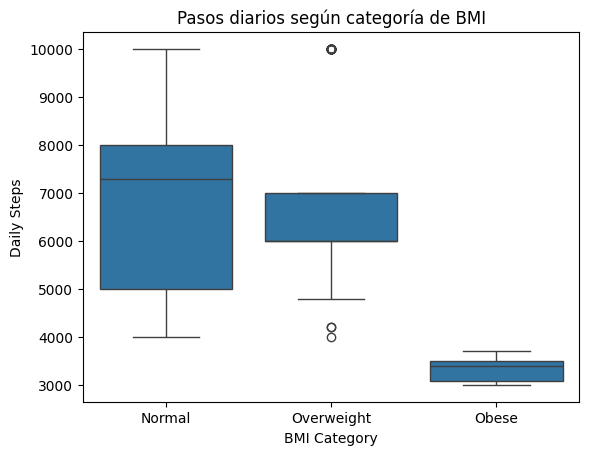

In [64]:
# distribución de pasos en cada categoría de BMI
sns.boxplot(data=data, x="BMI Category", y="Daily Steps",
            order=["Normal", "Overweight", "Obese"])
plt.title("Pasos diarios según categoría de BMI")
plt.show()

### CONCLUSIÓN DEL GRÁFICO
 Las personas con peso normal (mediana ≈ 7,300 pasos) y con sobrepeso
 (mediana ≈ 7,000) caminan bastante más que las personas con obesidad
 (mediana ≈ 3,400 pasos). Obese es la categoría con menos pasos y casi sin
 variabilidad, mientras que Normal es la más dispersa (de 4,000 a 10,000 pasos).
 La diferencia grande la marca la categoría Obese; Normal y Overweight son parecidos.

In [65]:
# promedio y mediana de pasos por categoría
print(data.groupby("BMI Category")["Daily Steps"].agg(["count", "mean", "median"]).round(0))

              count    mean  median
BMI Category                       
Normal          216  6875.0  7300.0
Obese            10  3350.0  3400.0
Overweight      148  6966.0  6000.0


In [66]:
# ¿hay diferencias de pasos entre categorías de BMI?
grupos = [g["Daily Steps"].values for _, g in data.groupby("BMI Category")]
h, p2 = stats.kruskal(*grupos)
print(f"Pasos vs BMI: H = {h:.2f}, p = {p2:.4g}")

Pasos vs BMI: H = 31.36, p = 1.553e-07


### CONCLUSIÓN FINAL:
 Pasos vs calidad del sueño: rho = 0.023 (p = 0.66), por lo que no existe una
 relación significativa. La cantidad de pasos diarios no afecta la calidad del sueño.
 Pasos vs BMI: Kruskal-Wallis dio H = 31.36 (p < 0.001), por lo que sí hay
 diferencias significativas. Las personas con obesidad caminan mucho menos
 (≈ 3,400 pasos) que las de peso normal (≈ 7,300) y sobrepeso (≈ 7,000).
 En resumen: los pasos diarios no se asocian con el sueño, pero sí con el BMI.

